# LFP spatial phase coherence vs distance (DIV 12)

Radial spatial phase-coherence analysis (`<cos(phi_i - phi_j)>` vs electrode separation, low-gamma
exp+cosine wavelength fit, activity-quartile split) for the ephaptic-axonal interference model.
Split out of `figure_3_lfp_event_front_compilation.ipynb`; the **event selection is shared** via the
`ephax.metrics.event_selection` backend (`compute_front_null_support` + `front_significant_events`,
`detect_well_bursts`, `peri_anchor_spike_counts`), so both notebooks analyse the identical
front-significant event set.

In [8]:
%matplotlib inline

import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax.metrics.lfp import (
    bandpass_downsample,
    dataset_for_well,
    extract_phasors,
    inspect_file,
    load_chunk,
    load_data_store_spikes,
)
from ephax.metrics.event_selection import (
    LFPWavefrontCacheConfig,
    LFPEventFrontBuildConfig,
    WellBurstConfig,
    FrontNullConfig,
    ensure_lfp_wavefront_caches,
    load_all_wavefront_caches,
    detect_well_bursts,
    peri_anchor_spike_counts,
    compute_front_null_support,
    front_significant_events,
)
from ephax.plotting import PAPER_COLORS, apply_paper_style
from ephax.plotting.style import LINE_WIDTHS, FONT_SIZES

apply_paper_style()
plt.rcParams["figure.dpi"] = 150
np.random.seed(0)

In [9]:
DIV = 12
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
EXAMPLE_WELL = 0
CACHE_PROFILE = "confirm"
LFP_SOURCE = "stim_removal_null_lfp"
BAND_LABEL = "30-50 Hz"
FS_DS = 500.0
SAVE_FIGURE = True
BOOTSTRAP_REPS = 10_000
BOOTSTRAP_SEED = 0
NULL_CORRECTION_ENABLED = True
NULL_CORRECTION_FORCE_RECOMPUTE = False
NULL_CORRECTION_REPS = 30
NULL_CORRECTION_SEED = 1
NULL_CORRECTION_TYPES = ["coordinate_shuffle", "arrival_time_shuffle"]
NULL_CORRECTION_MAX_EVENTS_PER_WELL = 25
NULL_FRONT_RADIUS_MM = 0.30
NULL_FRONT_MIN_NEIGHBORS = 8
NULL_FRONT_MAX_RADIUS_MM = 0.45
NULL_FRONT_MAX_NEIGHBORS = 24
NULL_FRONT_MIN_GEOMETRY_RATIO = 0.10
NULL_FRONT_MATCH_MAX_MS = 8.0
NULL_FRONT_MAX_RESIDUAL_MS = 4.0
NULL_FRONT_MIN_ARRIVAL_SPAN_MS = 1.0
NULL_FRONT_MIN_DISTANCE_SPAN_MM = 0.20
NULL_FRONT_MAX_SPEED_MM_PER_S = 500.0
SPEED_PANEL_MODE = "null_corrected"  # "null_corrected" or "all_qc_valid"
LFP_DIAGNOSTIC_PAD_S = 0.05
LFP_FILTER_CONTEXT_PAD_S = 0.25
TRACE_EXAMPLE_CHANNELS = 30
TRACE_EXAMPLE_GAIN = 8.0
SNAPSHOT_HEX_GRIDSIZE = 35
SNAPSHOT_HEX_MIN_VECTOR_COUNT = 3
SNAPSHOT_VECTOR_SCALE_MS = 2.2
SNAPSHOT_VECTOR_MAX_MM = 0.20
PHASE_COH_FREQ_LOW_HZ = 4.0
PHASE_COH_FREQ_HIGH_HZ = 180.0
PHASE_COH_N_BANDS = 28
PHASE_COH_REL_BANDWIDTH = 0.18
PHASE_COH_USE_ALL_CHANNELS = True
PHASE_COH_MAX_CHANNELS = None
TRACE_EXAMPLE_EVENT_IDX = None  # None selects the well-0 event with most valid local fits
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000
IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0

STIM_REMOVAL_NULL_LFP_FILE = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull") / f"DIV {int(DIV)}" / "data.raw.h5"
WAVE_CACHE_DIR = repo_root / "outputs" / "lfp_waves"
OUTPUT_DIR = repo_root / "outputs" / "figure3_lfp_event_front"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_NOTE = "Cached confirm burst-front screen, 30-50 Hz, 500 Hz"
FIGURE3_PRIMARY_COLOR = PAPER_COLORS["ephaptic_axonal"]
FIGURE3_PRIMARY_LIGHT = "#ead6f6"
FIGURE3_ACCENT_COLOR = PAPER_COLORS["highlight"]
FIGURE3_BURST_COLOR = PAPER_COLORS["burst"]


wavefront_cache_config = LFPWavefrontCacheConfig(
    source=LFP_SOURCE,
    profile=CACHE_PROFILE,
    div=DIV,
    band_low_hz=30.0,
    band_high_hz=50.0,
    fs_hz=FS_DS,
    lambda_min_mm=0.5,
    lambda_max_mm=10.0,
    radial=True,
    interval_mode="burst",
)

cache_paths = ensure_lfp_wavefront_caches(LFPEventFrontBuildConfig(
    raw_file=STIM_REMOVAL_NULL_LFP_FILE,
    cache_dir=WAVE_CACHE_DIR,
    cache=wavefront_cache_config,
    wells=tuple(AGGREGATE_WELLS),
    profile_calibration_events=None if CACHE_PROFILE == "confirm" else 25,
    profile_scoring_events=200 if CACHE_PROFILE == "confirm" else 15,
    min_amp=MIN_AMP,
    top_start=TOP_START,
    top_stop=TOP_STOP,
    ifr_grid_hz=IFR_GRID_HZ,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    highres_bin_ms=HIGHRES_BIN_MS,
    highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
    network_bin_ms=NETWORK_BIN_MS,
    network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    network_min_duration_ms=NETWORK_MIN_DURATION_MS,
    phase_pad_s=LFP_FILTER_CONTEXT_PAD_S,
    search_pre_ms=20.0,
    search_post_ms=40.0,
    match_max_ms=NULL_FRONT_MATCH_MAX_MS,
    radius_mm=NULL_FRONT_RADIUS_MM,
    min_neighbors=NULL_FRONT_MIN_NEIGHBORS,
    max_radius_mm=NULL_FRONT_MAX_RADIUS_MM,
    max_neighbors=NULL_FRONT_MAX_NEIGHBORS,
    min_geometry_ratio=NULL_FRONT_MIN_GEOMETRY_RATIO,
    max_residual_ms=NULL_FRONT_MAX_RESIDUAL_MS,
    min_arrival_span_ms=NULL_FRONT_MIN_ARRIVAL_SPAN_MS,
    min_distance_span_mm=NULL_FRONT_MIN_DISTANCE_SPAN_MM,
    max_speed_mm_per_s=NULL_FRONT_MAX_SPEED_MM_PER_S,
), build_missing=True)
AGGREGATE_WELLS = sorted(cache_paths)

if int(EXAMPLE_WELL) not in cache_paths:
    EXAMPLE_WELL = int(sorted(cache_paths)[0])
    print(f"EXAMPLE_WELL was unavailable; using well {EXAMPLE_WELL}.")

cache_manifest_df = pd.DataFrame([
    {"well": well, "cache_path": str(path), "cache_name": path.name}
    for well, path in sorted(cache_paths.items())
])
display(cache_manifest_df)
cache_paths


,well,cache_path,cache_name
0,0,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well0_...
1,1,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well1_...
2,2,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well2_...
3,3,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well3_...
4,4,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well4_...
5,5,/Users/danielrebbin/Documents/GitHub/ephax/out...,wavefront_stim_removal_null_lfp_confirm_well5_...


{0: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well0_DIV12_data0000_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 1: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well1_DIV12_data0001_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 2: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well2_DIV12_data0002_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 3: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well3_DIV12_data0003_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 4: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wavefront_stim_removal_null_lfp_confirm_well4_DIV12_data0004_burst_30-50Hz_fs500_lambda0.5-10_radial1.h5'),
 5: PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_waves/wave

In [10]:
# Radial-distance-disaggregated phase-coherence settings (pairwise-separation C(r))
PHASE_COH_DIST_N_BINS = 24        # number of linear electrode-separation bins
PHASE_COH_DIST_MAX_MM = None      # None -> auto from the maximum pairwise distance
PHASE_COH_DIST_MIN_PAIRS = 20     # distance bins with fewer pairs are masked (NaN)

In [11]:
calibration_df, calibration_summary_df, event_df, local_df = load_all_wavefront_caches(cache_paths)

local_df["valid"] = local_df["valid"].astype(bool)
valid_local_df = local_df.loc[local_df["valid"] & np.isfinite(local_df["speed_mm_per_s"])].copy()
event_speed_df = (
    valid_local_df.groupby(["well", "event_idx"], as_index=False)
    .agg(
        median_speed_mm_per_s=("speed_mm_per_s", "median"),
        mean_speed_mm_per_s=("speed_mm_per_s", "mean"),
        n_valid_local_fits=("speed_mm_per_s", "size"),
    )
)
print(f"Loaded {len(event_df)} events, {len(valid_local_df)} QC-valid local fits, {len(event_speed_df)} event medians.")

Loaded 1064 events, 536097 QC-valid local fits, 1064 event medians.


## Shared event selection: null-corrected front-significant events

Same backend call as figure 3 (`compute_front_null_support` + `front_significant_events`), so the
event set is identical by construction (same `local_df`, params and seed).

In [12]:
_front_null_cfg = FrontNullConfig(
    radius_mm=NULL_FRONT_RADIUS_MM, min_neighbors=NULL_FRONT_MIN_NEIGHBORS,
    max_radius_mm=NULL_FRONT_MAX_RADIUS_MM, max_neighbors=NULL_FRONT_MAX_NEIGHBORS,
    min_geometry_ratio=NULL_FRONT_MIN_GEOMETRY_RATIO, match_max_ms=NULL_FRONT_MATCH_MAX_MS,
    max_residual_ms=NULL_FRONT_MAX_RESIDUAL_MS, min_arrival_span_ms=NULL_FRONT_MIN_ARRIVAL_SPAN_MS,
    min_distance_span_mm=NULL_FRONT_MIN_DISTANCE_SPAN_MM, max_speed_mm_per_s=NULL_FRONT_MAX_SPEED_MM_PER_S,
)
front_null_df = compute_front_null_support(
    local_df, event_speed_df,
    null_types=NULL_CORRECTION_TYPES, reps=NULL_CORRECTION_REPS, seed=NULL_CORRECTION_SEED,
    max_events_per_well=NULL_CORRECTION_MAX_EVENTS_PER_WELL, cfg=_front_null_cfg,
    cache_path=OUTPUT_DIR / "tables" / f"spatial_null_support_DIV{int(DIV)}.csv",
    force_recompute=NULL_CORRECTION_FORCE_RECOMPUTE,
)
_corrected = front_significant_events(event_speed_df, front_null_df, support_quantile=0.95)
null_corrected_event_speed_df = _corrected.loc[
    _corrected["front_significant"].astype(bool) & np.isfinite(_corrected["median_speed_mm_per_s"])
].copy()
speed_panel_event_df = null_corrected_event_speed_df
_well_medians = null_corrected_event_speed_df.groupby("well")["median_speed_mm_per_s"].median()
speed_panel_hierarchical_summary = {"median_mm_per_s": float(_well_medians.median())}
print(f"Front-significant events: {len(null_corrected_event_speed_df)} across "
      f"{null_corrected_event_speed_df['well'].nunique()} wells; "
      f"v_eph (hierarchical median) = {speed_panel_hierarchical_summary['median_mm_per_s'] / 1000.0:.3f} mm/ms")

Front-significant events: 115 across 6 wells; v_eph (hierarchical median) = 0.084 mm/ms


In [13]:
WELL_BURST_CFG = WellBurstConfig(
    min_amp=MIN_AMP, top_start=TOP_START, top_stop=TOP_STOP,
    ifr_grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    highres_bin_ms=HIGHRES_BIN_MS, highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
    network_bin_ms=NETWORK_BIN_MS,
    network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    network_min_duration_ms=NETWORK_MIN_DURATION_MS,
)


def detect_example_well_bursts(well):
    return detect_well_bursts(STIM_REMOVAL_NULL_LFP_FILE, dataset_for_well(well), cfg=WELL_BURST_CFG)

In [14]:
_ex_events = speed_panel_event_df.loc[speed_panel_event_df["well"] == int(EXAMPLE_WELL)]
if _ex_events.empty:
    EXAMPLE_WELL = int(sorted(speed_panel_event_df["well"].unique())[0])
    _ex_events = speed_panel_event_df.loc[speed_panel_event_df["well"] == int(EXAMPLE_WELL)]
_ex = _ex_events.sort_values("n_valid", ascending=False).iloc[0]
_ex_event_idx = int(_ex["event_idx"])
_ex_anchor = float(event_df.loc[
    (event_df["well"].astype(int) == int(EXAMPLE_WELL)) & (event_df["event_idx"].astype(int) == _ex_event_idx),
    "anchor_time_s"].iloc[0])
_ex_bursts, _ex_info = detect_example_well_bursts(int(EXAMPLE_WELL))
_j = int(np.argmin(np.abs(_ex_bursts["anchor_time_s"].to_numpy(float) - _ex_anchor)))
_ex_core = (float(_ex_bursts["start_time_s"].iloc[_j]), float(_ex_bursts["end_time_s"].iloc[_j]))
_rec_stop = _ex_info["raw_shape"][1] / _ex_info["fs_raw"]
example_trace_data = {
    "well": int(EXAMPLE_WELL), "event_idx": _ex_event_idx, "anchor_time_s": _ex_anchor,
    "core_interval_s": _ex_core,
    "display_interval_s": (max(0.0, _ex_core[0] - LFP_DIAGNOSTIC_PAD_S), min(_rec_stop, _ex_core[1] + LFP_DIAGNOSTIC_PAD_S)),
    "filter_interval_s": (max(0.0, _ex_core[0] - LFP_FILTER_CONTEXT_PAD_S), min(_rec_stop, _ex_core[1] + LFP_FILTER_CONTEXT_PAD_S)),
}
print(f"Example event: well {EXAMPLE_WELL}, event {_ex_event_idx}, core "
      f"{_ex_core[0]:.3f}-{_ex_core[1]:.3f}s")

Example event: well 0, event 113, core 366.340-366.400s


## Standalone phase-coherence diagnostic

Two complementary views of the example event's LFP phase field, over a bank of
log-spaced frequency bands:

1. **Global spatial coherence** — the order-parameter magnitude `R(t) = |mean over channels of the unit phasors|`
   per band and time sample, i.e. how phase-aligned the *whole* array is at each instant.
2. **Spatial coherence vs. electrode separation** — the instantaneous phase alignment
   `<cos(phi_i - phi_j)>` averaged over the burst core window and binned by separation distance `||xi - xj||`.
   This is the distance-resolved decomposition of the aggregate order parameter (`R^2` equals the mean of
   `cos(dphi)` over all pairs), so it reads ~0 where the field is spatially incoherent and ~1 only where
   channels are genuinely in phase — revealing the coherence length of gamma vs. lower-frequency bands.
   A time-averaged PLV is **not** used here: for a narrowband pair the phase difference is nearly constant,
   so `|<exp(i dphi)>_t|` is trivially ~1 regardless of true coupling. Distance bins are controlled by
   `PHASE_COH_DIST_*`; the pairwise math reuses the per-band phasors, so it adds negligible runtime.

Phase-coherence heatmap: 1020 channels, 28 log-spaced bands, 366.290-366.450s


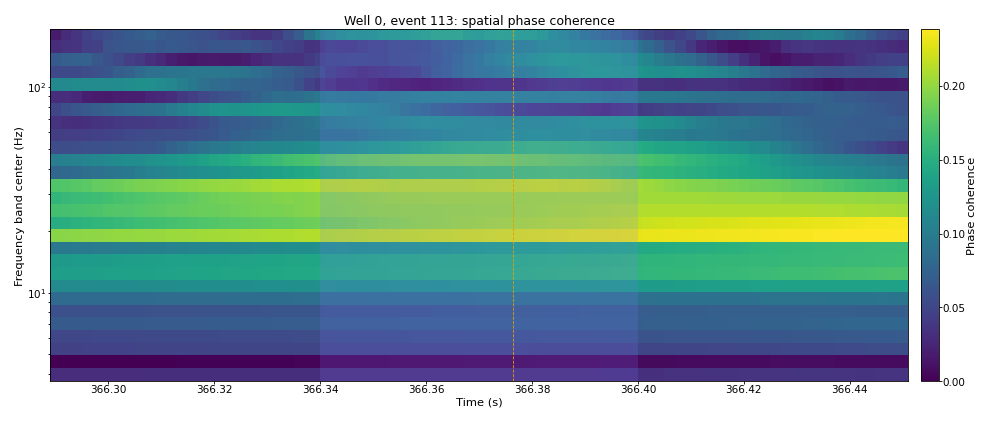

Distance-frequency coherence: 24 separation bins 0-4.08 mm, 28 bands, core window 366.340-366.400s (31 samples)


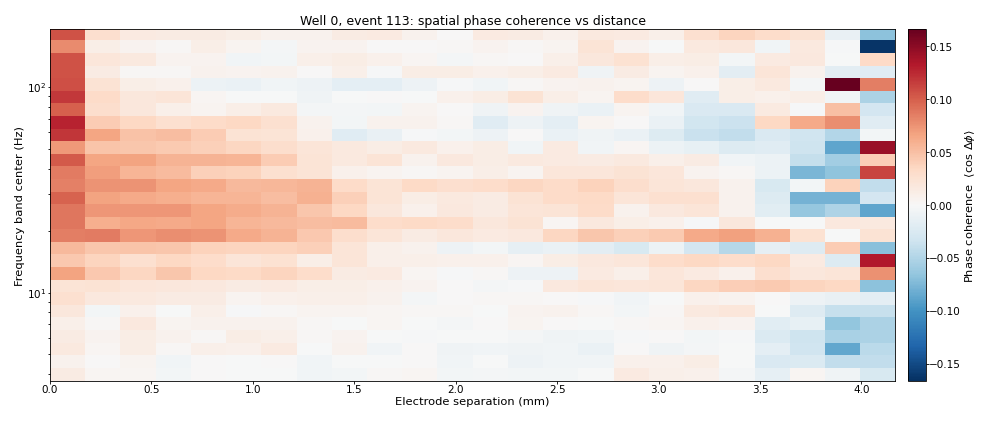

In [15]:
def make_log_frequency_bands(low_hz, high_hz, n_bands, rel_bandwidth, *, fs_ds=500.0):
    centers = np.geomspace(float(low_hz), float(high_hz), int(n_bands))
    nyquist = 0.5 * float(fs_ds)
    bands = []
    for center in centers:
        half_width = 0.5 * float(rel_bandwidth) * center
        band_low = max(0.25, center - half_width)
        band_high = min(0.98 * nyquist, center + half_width)
        if band_high <= band_low:
            continue
        bands.append((float(center), float(band_low), float(band_high)))
    return pd.DataFrame(bands, columns=["center_hz", "low_hz", "high_hz"])


def pairwise_distance_bins(coords_mm, n_bins, max_mm=None):
    """Upper-triangle electrode-pair distances and their linear-bin assignment.

    Returns the row/col index arrays for the upper triangle (i<j), each pair's
    separation in mm, its distance-bin index, per-bin pair counts, and the bin
    edges/centers. Pairs beyond ``max_mm`` (when given explicitly) are dropped.
    """
    coords = np.asarray(coords_mm, dtype=float)
    iu = np.triu_indices(coords.shape[0], 1)
    diff = coords[iu[0]] - coords[iu[1]]
    d = np.sqrt(np.einsum("ij,ij->i", diff, diff))
    hi = float(max_mm) if max_mm is not None else float(d.max())
    in_range = d <= hi
    iu0, iu1, d = iu[0][in_range], iu[1][in_range], d[in_range]
    edges = np.linspace(0.0, hi, int(n_bins) + 1)
    bin_idx = np.clip(np.digitize(d, edges) - 1, 0, int(n_bins) - 1)
    counts = np.bincount(bin_idx, minlength=int(n_bins)).astype(float)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return {
        "iu0": iu0,
        "iu1": iu1,
        "distances_mm": d,
        "bin_idx": bin_idx,
        "counts": counts,
        "edges_mm": edges,
        "centers_mm": centers,
    }


def compute_example_phase_coherence_heatmap(trace, *, use_all_channels=True, max_channels=None):
    well = int(trace["well"])
    dataset = dataset_for_well(well)
    info = inspect_file(STIM_REMOVAL_NULL_LFP_FILE, dataset)
    filter_interval = tuple(float(v) for v in trace["filter_interval_s"])
    display_interval = tuple(float(v) for v in trace["display_interval_s"])
    core_interval = tuple(float(v) for v in trace["core_interval_s"])
    start_frame = int(round(filter_interval[0] * info["fs_raw"]))
    n_frames = max(1, int(round((filter_interval[1] - filter_interval[0]) * info["fs_raw"])))
    raw_full, coords_mm, fs_raw, mapping = load_chunk(STIM_REMOVAL_NULL_LFP_FILE, dataset, start_frame, n_frames)
    channel_ids = np.asarray(mapping["channel"])
    if use_all_channels:
        channel_idx = np.arange(raw_full.shape[1])
    else:
        selected = np.asarray(trace["channels"])
        channel_idx = np.flatnonzero(np.isin(channel_ids, selected))
    if max_channels is not None and channel_idx.size > int(max_channels):
        pick = np.round(np.linspace(0, channel_idx.size - 1, int(max_channels))).astype(int)
        channel_idx = channel_idx[pick]
    if channel_idx.size == 0:
        raise ValueError("No channels available for phase-coherence heatmap")
    raw_selected = raw_full[:, channel_idx]
    coords_sel = np.asarray(coords_mm, dtype=float)[channel_idx]
    dist_bins = pairwise_distance_bins(coords_sel, PHASE_COH_DIST_N_BINS, PHASE_COH_DIST_MAX_MM)
    bands = make_log_frequency_bands(
        PHASE_COH_FREQ_LOW_HZ,
        PHASE_COH_FREQ_HIGH_HZ,
        PHASE_COH_N_BANDS,
        PHASE_COH_REL_BANDWIDTH,
        fs_ds=FS_DS,
    )
    coherence_rows = []
    distance_rows = []
    t_ds_full = None
    display_mask = None
    core_mask = None
    core_n_samples = 0
    for _, row in bands.iterrows():
        band_ds = bandpass_downsample(
            raw_selected,
            fs_raw,
            float(row["low_hz"]),
            float(row["high_hz"]),
            FS_DS,
            max_channels_per_block=128,
        )
        if t_ds_full is None:
            t_ds_full = filter_interval[0] + np.arange(band_ds.shape[0]) / FS_DS
            display_mask = (t_ds_full >= display_interval[0]) & (t_ds_full <= display_interval[1])
            core_mask = (t_ds_full >= core_interval[0]) & (t_ds_full <= core_interval[1])
            if int(core_mask.sum()) < 2:  # burst core too short to average; fall back to display window
                core_mask = display_mask
            core_n_samples = int(core_mask.sum())
        u, _ = extract_phasors(band_ds)
        coherence = np.abs(np.nanmean(u, axis=1))
        coherence_rows.append(coherence[display_mask])
        # Spatial phase coherence vs electrode separation: <cos(phi_i - phi_j)>
        # over the core window. This mirrors the aggregate instantaneous order
        # parameter R(t) = |mean_i u_i(t)| (R^2 = mean over pairs of cos(dphi)),
        # decomposed by distance. Unlike a time-averaged PLV -- |<exp(i dphi)>_t|,
        # which is trivially ~1 for a narrowband pair -- it is 0 when the field is
        # spatially incoherent and ~1 only when channels are genuinely in phase.
        u_core = u[core_mask, :]
        valid = (np.abs(u_core) > 0).astype(np.float32)
        cross = u_core.conj().T @ u_core            # (N, N) complex cross-spectrum
        joint = valid.T @ valid                      # (N, N) jointly-valid sample counts
        cos_dphi = np.real(cross) / np.maximum(joint, 1.0)
        coh_pairs = cos_dphi[dist_bins["iu0"], dist_bins["iu1"]]
        sums = np.bincount(dist_bins["bin_idx"], weights=coh_pairs, minlength=PHASE_COH_DIST_N_BINS)
        counts = dist_bins["counts"]
        c_r = np.full(PHASE_COH_DIST_N_BINS, np.nan)
        np.divide(sums, counts, out=c_r, where=counts > 0)
        c_r[counts < PHASE_COH_DIST_MIN_PAIRS] = np.nan
        distance_rows.append(c_r)
    coherence = np.vstack(coherence_rows)
    distance_coherence = np.vstack(distance_rows)
    return {
        "well": well,
        "event_idx": int(trace["event_idx"]),
        "anchor_time_s": float(trace["anchor_time_s"]),
        "core_interval_s": core_interval,
        "display_interval_s": display_interval,
        "filter_interval_s": filter_interval,
        "time_s": t_ds_full[display_mask],
        "bands": bands,
        "coherence": coherence,
        "distance_coherence": distance_coherence,
        "distance_bin_centers_mm": dist_bins["centers_mm"],
        "distance_bin_pair_counts": dist_bins["counts"],
        "core_window_n_samples": core_n_samples,
        "n_channels": int(channel_idx.size),
    }


def draw_phase_coherence_heatmap(coherence_data, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 2.8), constrained_layout=True)
    time_s = np.asarray(coherence_data["time_s"], dtype=float)
    bands = coherence_data["bands"]
    centers = bands["center_hz"].to_numpy(float)
    coherence = np.asarray(coherence_data["coherence"], dtype=float)
    vmax = float(np.nanmax(coherence)) if np.any(np.isfinite(coherence)) else 1.0
    vmax = max(vmax, np.finfo(float).eps)
    mesh = ax.pcolormesh(time_s, centers, coherence, shading="auto", cmap="viridis", vmin=0.0, vmax=vmax)
    core = coherence_data["core_interval_s"]
    ax.axvspan(core[0], core[1], color=FIGURE3_PRIMARY_COLOR, alpha=0.16, linewidth=0)
    ax.axvline(coherence_data["anchor_time_s"], color=FIGURE3_ACCENT_COLOR, lw=LINE_WIDTHS["base"], ls="--")
    ax.set_yscale("log")
    ax.set(
        xlabel="Time (s)",
        ylabel="Frequency band center (Hz)",
        title=f"Well {coherence_data['well']}, event {coherence_data['event_idx']}: spatial phase coherence",
    )
    cbar = ax.figure.colorbar(mesh, ax=ax, pad=0.015)
    cbar.set_label("Phase coherence")
    return {"mappable": mesh, "colorbar": cbar}


def draw_distance_frequency_coherence_heatmap(coherence_data, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 2.8), constrained_layout=True)
    dist_centers = np.asarray(coherence_data["distance_bin_centers_mm"], dtype=float)
    bands = coherence_data["bands"]
    centers = bands["center_hz"].to_numpy(float)
    coherence = np.ma.masked_invalid(np.asarray(coherence_data["distance_coherence"], dtype=float))
    vmax = float(np.abs(coherence).max()) if coherence.count() else 1.0
    vmax = max(vmax, np.finfo(float).eps)
    # signed coherence (<cos dphi> in [-1, 1]); diverging map centred on 0 = incoherent.
    mesh = ax.pcolormesh(dist_centers, centers, coherence, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_yscale("log")
    ax.set(
        xlabel="Electrode separation (mm)",
        ylabel="Frequency band center (Hz)",
        title=f"Well {coherence_data['well']}, event {coherence_data['event_idx']}: spatial phase coherence vs distance",
    )
    cbar = ax.figure.colorbar(mesh, ax=ax, pad=0.015)
    cbar.set_label(r"Phase coherence  $\langle\cos\,\Delta\phi\rangle$")
    return {"mappable": mesh, "colorbar": cbar}


phase_coherence_data = compute_example_phase_coherence_heatmap(
    example_trace_data,
    use_all_channels=PHASE_COH_USE_ALL_CHANNELS,
    max_channels=PHASE_COH_MAX_CHANNELS,
)
print(
    f"Phase-coherence heatmap: {phase_coherence_data['n_channels']} channels, "
    f"{len(phase_coherence_data['bands'])} log-spaced bands, "
    f"{phase_coherence_data['display_interval_s'][0]:.3f}-{phase_coherence_data['display_interval_s'][1]:.3f}s"
)

fig, ax = plt.subplots(figsize=(6.5, 2.7), constrained_layout=True)
draw_phase_coherence_heatmap(phase_coherence_data, ax=ax)
plt.show()

print(
    f"Distance-frequency coherence: {phase_coherence_data['distance_coherence'].shape[1]} separation bins "
    f"0-{phase_coherence_data['distance_bin_centers_mm'][-1]:.2f} mm, "
    f"{len(phase_coherence_data['bands'])} bands, core window "
    f"{phase_coherence_data['core_interval_s'][0]:.3f}-{phase_coherence_data['core_interval_s'][1]:.3f}s "
    f"({phase_coherence_data['core_window_n_samples']} samples)"
)

fig, ax = plt.subplots(figsize=(6.5, 2.7), constrained_layout=True)
draw_distance_frequency_coherence_heatmap(phase_coherence_data, ax=ax)
plt.show()

## Burst-interval-averaged phase-coherence spectrum (all downstream events)

The per-event heatmap above is a single event (the one with most valid QC fits). Here we collapse
the time axis to the **burst interval** and average the spatial phase coherence over the log-spaced
frequency bands for **every valid event that enters the downstream speed panel** (`speed_panel_event_df`).
Each event's coherence(frequency) curve is pooled across events (event-level bootstrap 95% CI); the
30–50 Hz wavefront band is shaded. *Heavy:* one raw-LFP load + 28 band filters per event — set
`COH_SPECTRUM_MAX_EVENTS_PER_WELL` to cap for a quick preview.

In [16]:
# --- Per-event coherence caching -----------------------------------------------------------------
# The coherence-spectrum and distance-map loops below refilter the same per-event LFP on every run
# (~8 min/well and ~15-20 min respectively). These helpers persist each event's result to disk keyed
# by (well, event_idx, core interval) plus a config signature, so reruns only recompute events that
# are new or whose parameters changed. Results are byte-identical to recomputing. Set
# COH_CACHE_FORCE_RECOMPUTE = True to rebuild from scratch.
import pickle

COH_CACHE_DIR = OUTPUT_DIR / "coherence_cache"
COH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
COH_CACHE_FORCE_RECOMPUTE = False

def _load_event_cache(path, signature):
    """Return the cached {key: value} dict when the stored config signature matches, else {}."""
    path = Path(path)
    if COH_CACHE_FORCE_RECOMPUTE or not path.exists():
        return {}
    try:
        blob = pickle.loads(path.read_bytes())
    except Exception:
        return {}
    return dict(blob.get("data", {})) if blob.get("signature") == signature else {}

def _save_event_cache(path, signature, data):
    Path(path).write_bytes(pickle.dumps({"signature": signature, "data": data}))

In [17]:
# --- Coherence setup: bands, event set, core intervals, and the fused per-event compute ---
from scipy.optimize import curve_fit
from scipy.stats import chi2 as _chi2_dist

# Global-order-parameter spectrum settings
COH_SPECTRUM_BOOTSTRAP_REPS = 2000
COH_SPECTRUM_SEED = 0
# Distance-resolved <cos dphi> settings
COHDIST_LOWGAMMA_HZ = (30.0, 50.0)
COHDIST_N_DIST_BINS = 24
COHDIST_MAX_DIST_MM = 4.0
COHDIST_FIT_MAX_DIST_MM = 3.5
COHDIST_FIT_MIN_DIST_MM = 0.2
COHDIST_MIN_PAIRS = 50
COHDIST_BOOTSTRAP_REPS = 200
COHDIST_SEED = 0
COHDIST_MODEL_F_HZ = float(globals().get("IFR_PEAK_HZ", 37.76))
COHDIST_MODEL_VAX_MM_PER_MS = 0.62

coh_bands = make_log_frequency_bands(
    PHASE_COH_FREQ_LOW_HZ, PHASE_COH_FREQ_HIGH_HZ, PHASE_COH_N_BANDS, PHASE_COH_REL_BANDWIDTH, fs_ds=FS_DS,
)
coh_band_centers = coh_bands["center_hz"].to_numpy(float)
cohdist_edges = np.linspace(0.0, COHDIST_MAX_DIST_MM, COHDIST_N_DIST_BINS + 1)
cohdist_centers = 0.5 * (cohdist_edges[:-1] + cohdist_edges[1:])

_coh_burst_cache = {}

def _event_core_interval(well, anchor_time_s):
    """Burst (start, end) for the event, matched to the anchor."""
    if well not in _coh_burst_cache:
        bursts, _ = detect_example_well_bursts(well)
        _coh_burst_cache[well] = bursts
    bursts = _coh_burst_cache[well]
    j = int(np.argmin(np.abs(bursts["anchor_time_s"].to_numpy(float) - float(anchor_time_s))))
    return float(bursts["start_time_s"].iloc[j]), float(bursts["end_time_s"].iloc[j])


def event_phase_coherence(well, core_interval_s, dist_edges, *, min_pairs=COHDIST_MIN_PAIRS):
    """ONE filtering pass -> both the global coherence spectrum AND the <cos(phi_i-phi_j)> distance map.

    Filtering matches the paper exactly (per-band bandpass_downsample: filter @ raw rate, then
    downsample), so results are bit-identical to computing the two quantities in separate passes.
    Returns (spectrum (n_bands,), distance_map (n_bands, n_bins), pair_counts (n_bins,)).
    """
    dataset = dataset_for_well(well)
    info = inspect_file(STIM_REMOVAL_NULL_LFP_FILE, dataset)
    rec_stop = info["raw_shape"][1] / info["fs_raw"]
    core0, core1 = float(core_interval_s[0]), float(core_interval_s[1])
    filt0 = max(0.0, core0 - LFP_FILTER_CONTEXT_PAD_S)
    filt1 = min(rec_stop, core1 + LFP_FILTER_CONTEXT_PAD_S)
    start_frame = int(round(filt0 * info["fs_raw"]))
    n_frames = max(1, int(round((filt1 - filt0) * info["fs_raw"])))
    raw, coords_mm, fs_raw, _ = load_chunk(STIM_REMOVAL_NULL_LFP_FILE, dataset, start_frame, n_frames)
    coords_mm = np.asarray(coords_mm, dtype=float)
    n_bins = len(dist_edges) - 1
    iu = np.triu_indices(coords_mm.shape[0], 1)
    d = np.linalg.norm(coords_mm[iu[0]] - coords_mm[iu[1]], axis=1)
    in_range = d <= dist_edges[-1]
    iu0, iu1, d = iu[0][in_range], iu[1][in_range], d[in_range]
    bin_idx = np.clip(np.digitize(d, dist_edges) - 1, 0, n_bins - 1)
    counts = np.bincount(bin_idx, minlength=n_bins).astype(float)
    spec = np.full(len(coh_bands), np.nan)
    coh_map = np.full((len(coh_bands), n_bins), np.nan)
    t_ds = None
    core_mask = None
    for bi, row in enumerate(coh_bands.itertuples(index=False)):
        band_ds = bandpass_downsample(raw, fs_raw, float(row.low_hz), float(row.high_hz), FS_DS, max_channels_per_block=128)
        if t_ds is None:
            t_ds = filt0 + np.arange(band_ds.shape[0]) / FS_DS
            core_mask = (t_ds >= core0) & (t_ds <= core1)
            if int(core_mask.sum()) < 2:
                core_mask = np.ones(t_ds.shape, dtype=bool)
        u, _ = extract_phasors(band_ds)
        spec[bi] = float(np.nanmean(np.abs(np.nanmean(u, axis=1))[core_mask]))
        uc = u[core_mask, :]
        valid = (np.abs(uc) > 0).astype(np.float32)
        cross = uc.conj().T @ uc
        joint = np.maximum(valid.T @ valid, 1.0)
        cos_dphi = np.real(cross) / joint
        sums = np.bincount(bin_idx, weights=cos_dphi[iu0, iu1], minlength=n_bins)
        c_r = np.full(n_bins, np.nan)
        np.divide(sums, counts, out=c_r, where=counts > 0)
        c_r[counts < min_pairs] = np.nan
        coh_map[bi] = c_r
    return spec, coh_map, counts


# downstream (front-significant) events with their anchors
coh_downstream = (
    speed_panel_event_df[["well", "event_idx"]].astype(int).drop_duplicates()
    .merge(event_df[["well", "event_idx", "anchor_time_s"]].astype({"well": int, "event_idx": int}).drop_duplicates(["well", "event_idx"]),
           on=["well", "event_idx"], how="left")
    .dropna(subset=["anchor_time_s"]).sort_values(["well", "anchor_time_s"]).reset_index(drop=True)
)
print(f"downstream event set: {len(coh_downstream)} events across {coh_downstream['well'].nunique()} wells")

downstream event set: 115 events across 6 wells


In [18]:
# --- Fused, parallel per-event compute (bit-identical to the serial two-pass version) ---
# One filtering pass per event (not two), distributed across CPU cores. Results are cached per event.
from joblib import Parallel, delayed

_coh_cache_sig = {
    "kind": "phase_coherence_fused", "div": int(DIV), "file": STIM_REMOVAL_NULL_LFP_FILE.name, "fs_ds": float(FS_DS),
    "flo": PHASE_COH_FREQ_LOW_HZ, "fhi": PHASE_COH_FREQ_HIGH_HZ, "nbands": int(PHASE_COH_N_BANDS),
    "relbw": PHASE_COH_REL_BANDWIDTH, "allch": bool(PHASE_COH_USE_ALL_CHANNELS), "maxch": PHASE_COH_MAX_CHANNELS,
    "pad": LFP_FILTER_CONTEXT_PAD_S, "edges": tuple(round(float(e), 5) for e in cohdist_edges),
    "min_pairs": int(COHDIST_MIN_PAIRS), "ver": 1,
}
_coh_cache_path = COH_CACHE_DIR / "event_phase_coherence_cache.pkl"
_coh_cache = _load_event_cache(_coh_cache_path, _coh_cache_sig)

# resolve burst core intervals serially (detect_well_bursts is cached per well in _coh_burst_cache)
_tasks = []
for _well in sorted(coh_downstream["well"].unique()):
    for _r in coh_downstream[coh_downstream["well"] == _well].itertuples(index=False):
        try:
            _core = _event_core_interval(int(_well), float(_r.anchor_time_s))
            _tasks.append((int(_well), int(_r.event_idx), (float(_core[0]), float(_core[1]))))
        except Exception as exc:
            print(f"  well {int(_well)} event {int(_r.event_idx)}: core-interval skipped ({exc})")

def _key(well, event_idx, core):
    return (int(well), int(event_idx), round(core[0], 4), round(core[1], 4))

_missing = [(w, e, core) for (w, e, core) in _tasks if _key(w, e, core) not in _coh_cache]
print(f"phase coherence: {len(_tasks)} events, {len(_missing)} to compute, {len(_tasks) - len(_missing)} from cache")
if _missing:
    try:
        _results = Parallel(n_jobs=-1, verbose=5)(
            delayed(event_phase_coherence)(w, core, cohdist_edges) for (w, e, core) in _missing
        )
    except Exception as _exc:
        print(f"parallel compute unavailable ({_exc}); falling back to serial")
        _results = [event_phase_coherence(w, core, cohdist_edges) for (w, e, core) in _missing]
    for (w, e, core), res in zip(_missing, _results):
        _coh_cache[_key(w, e, core)] = res
    _save_event_cache(_coh_cache_path, _coh_cache_sig, _coh_cache)

# assemble aggregate arrays in event order
coh_spectra, coh_meta, cohdist_maps, cohdist_counts, cohdist_meta = [], [], [], [], []
for (w, e, core) in _tasks:
    res = _coh_cache.get(_key(w, e, core))
    if res is None:
        continue
    spec, cmap, counts = res
    coh_spectra.append(spec); coh_meta.append((w, e))
    cohdist_maps.append(cmap); cohdist_counts.append(counts); cohdist_meta.append((w, e))
if not coh_spectra:
    raise RuntimeError("No downstream-event coherence was computed.")
coh_matrix = np.vstack(coh_spectra)                       # (n_events, n_bands)
cohdist_maps = np.asarray(cohdist_maps)                   # (n_events, n_bands, n_bins)
cohdist_counts = np.asarray(cohdist_counts)
cohdist_pair_counts = np.nanmean(cohdist_counts, axis=0)
cohdist_meta_df = pd.DataFrame(cohdist_meta, columns=["well", "event_idx"])
print(f"aggregated {coh_matrix.shape[0]} events x {coh_matrix.shape[1]} bands; "
      f"distance maps {cohdist_maps.shape}")

phase coherence: 115 events, 115 to compute, 0 from cache


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: 

aggregated 115 events x 28 bands; distance maps (115, 28, 24)


[Parallel(n_jobs=-1)]: Done 115 out of 115 | elapsed:  4.4min finished


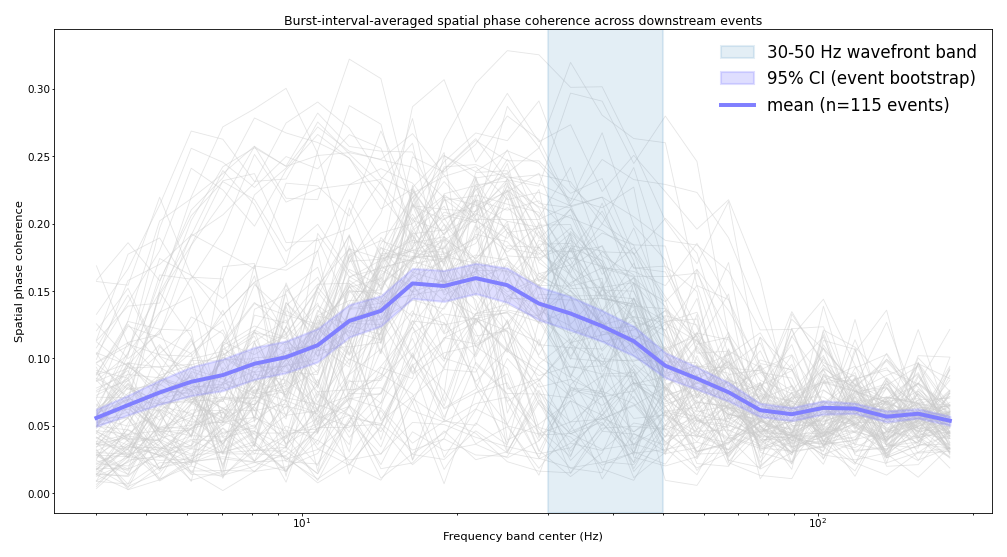

In [19]:
# --- Global spatial-coherence spectrum: event bootstrap + figure ---
_rng = np.random.default_rng(COH_SPECTRUM_SEED)
coh_mean = np.nanmean(coh_matrix, axis=0)
_boot = np.empty((int(COH_SPECTRUM_BOOTSTRAP_REPS), coh_matrix.shape[1]))
for b in range(int(COH_SPECTRUM_BOOTSTRAP_REPS)):
    _boot[b] = np.nanmean(coh_matrix[_rng.integers(0, coh_matrix.shape[0], coh_matrix.shape[0])], axis=0)
coh_ci_lo = np.nanpercentile(_boot, 2.5, axis=0)
coh_ci_hi = np.nanpercentile(_boot, 97.5, axis=0)

coh_spectrum_df = pd.DataFrame({
    "center_hz": coh_band_centers, "coherence_mean": coh_mean,
    "coherence_ci_low": coh_ci_lo, "coherence_ci_high": coh_ci_hi,
    "n_events": int(coh_matrix.shape[0]), "n_wells": int(len(set(m[0] for m in coh_meta))),
})
coh_spectrum_df.to_csv(OUTPUT_DIR / "burst_coherence_spectrum_by_frequency.csv", index=False)

fig, ax = plt.subplots(figsize=(6.6, 3.6), constrained_layout=True)
for spec in coh_matrix:
    ax.plot(coh_band_centers, spec, color="0.8", lw=0.4, alpha=0.5, zorder=0)
ax.axvspan(30.0, 50.0, color=FIGURE3_BURST_COLOR, alpha=0.12, zorder=0, label="30-50 Hz wavefront band")
ax.fill_between(coh_band_centers, coh_ci_lo, coh_ci_hi, color=FIGURE3_PRIMARY_COLOR, alpha=0.25, label="95% CI (event bootstrap)")
ax.plot(coh_band_centers, coh_mean, color=FIGURE3_PRIMARY_COLOR, lw=1.9, label=f"mean (n={coh_matrix.shape[0]} events)")
ax.set_xscale("log")
ax.set_xlabel("Frequency band center (Hz)")
ax.set_ylabel("Spatial phase coherence")
ax.set_title("Burst-interval-averaged spatial phase coherence across downstream events")
ax.legend(frameon=False, fontsize=8)
fig.savefig(OUTPUT_DIR / "burst_coherence_spectrum.png", dpi=130, bbox_inches="tight")
plt.show()

## Event-aggregated spatial phase coherence vs distance

Pools the corrected spatial coherence `<cos(phi_i - phi_j)>` across the front-significant events
(`coh_downstream`), resolved by frequency band and electrode separation. The aggregate low-gamma
`C(r)` is fitted with an exponential-only vs exponential+cosine model to quantify the interference
wavelength predicted by the ephaptic-axonal model, `lambda = 1 / [ f (1/v_eph - 1/v_ax) ]`. Uncertainty
is a percentile bootstrap over events; the fit is restricted to the well-sampled separation range.

/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_70000/3596112546.py:22: RuntimeWarning: Mean of empty slice
  event_lowgamma_cr = np.nanmean(cohdist_maps[:, lowgamma_mask, :], axis=1)   # (n_events, n_bins)


n_events=115, low-gamma 30-50 Hz
fitted wavelength = 2.92 mm (95% CI 2.77-3.05); model prediction = 2.56 mm
RSS reduction (exp -> exp+cos) = 84.5%; LRT chi2=37.3 p=7.86e-09; dBIC=-31.3


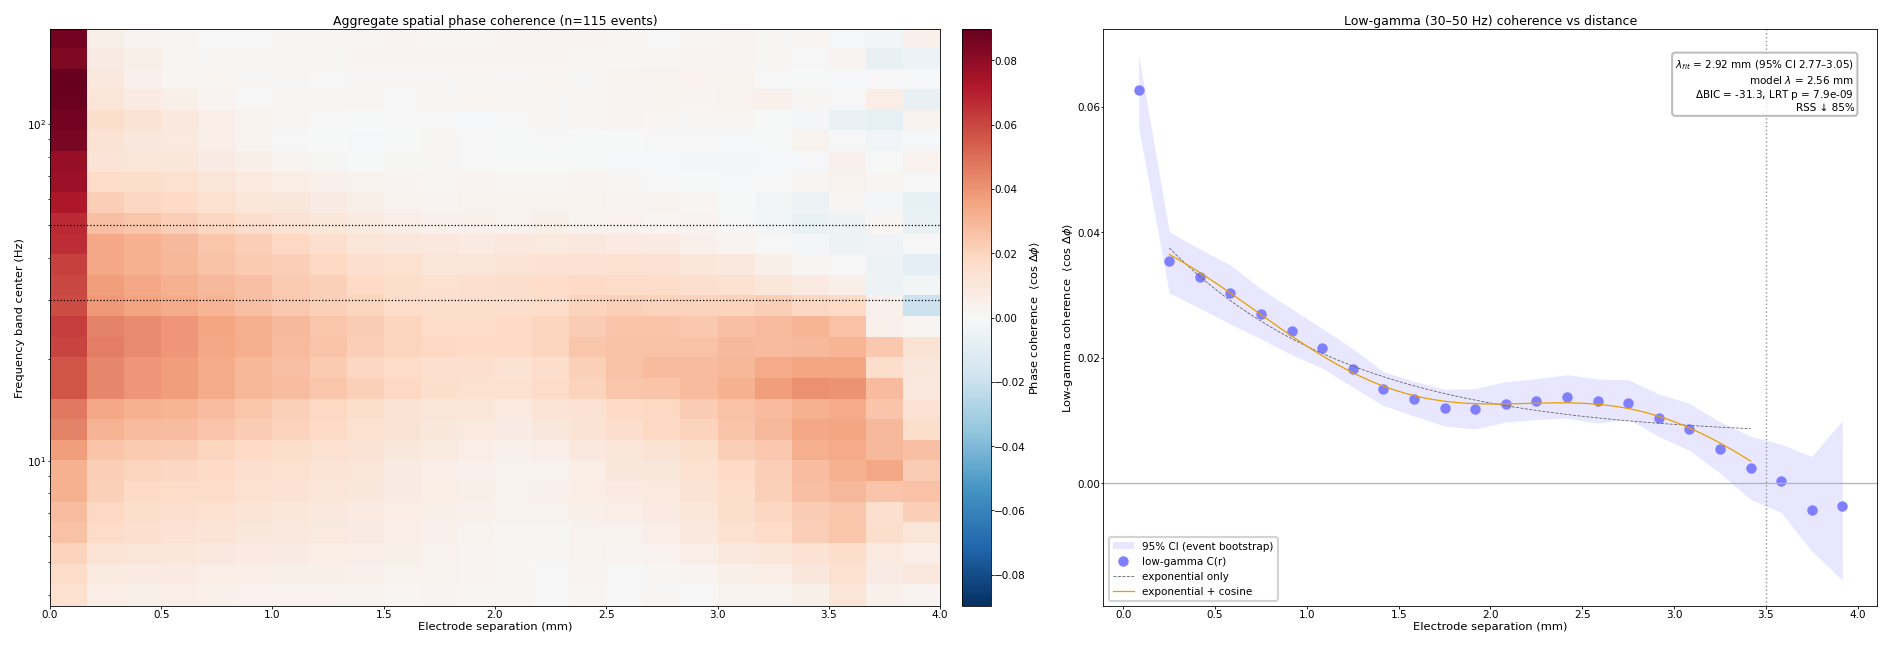

In [20]:
# --- Aggregate coherence-vs-distance: bootstrap CIs + exponential vs exponential+cosine model fit ---

def _coh_exp_model(r, a, lam, b):
    return a * np.exp(-r / lam) + b

def _coh_expcos_model(r, a, lam, b, c, wavelength):
    return a * np.exp(-r / lam) + b + c * np.cos(2.0 * np.pi * r / wavelength)

def _fit_coh_models(r, y, weights):
    sigma = 1.0 / np.sqrt(np.maximum(weights, 1e-9))
    p_exp, _ = curve_fit(_coh_exp_model, r, y, p0=[max(y.max() - y.min(), 1e-3), 1.0, float(np.median(y))],
                         sigma=sigma, maxfev=40000, bounds=([0.0, 0.05, -1.0], [3.0, 20.0, 1.0]))
    p_full, _ = curve_fit(_coh_expcos_model, r, y, p0=[*p_exp, 0.05, 2.3],
                          sigma=sigma, maxfev=80000,
                          bounds=([0.0, 0.05, -1.0, 0.0, 1.0], [3.0, 20.0, 1.0, 1.0, 4.0]))
    rss_exp = float(np.sum(weights * (y - _coh_exp_model(r, *p_exp)) ** 2))
    rss_full = float(np.sum(weights * (y - _coh_expcos_model(r, *p_full)) ** 2))
    return p_exp, p_full, rss_exp, rss_full

# --- low-gamma C(r): pool across events, bootstrap over events ---
lowgamma_mask = (coh_band_centers >= COHDIST_LOWGAMMA_HZ[0]) & (coh_band_centers <= COHDIST_LOWGAMMA_HZ[1])
event_lowgamma_cr = np.nanmean(cohdist_maps[:, lowgamma_mask, :], axis=1)   # (n_events, n_bins)
pooled_cr = np.nanmean(event_lowgamma_cr, axis=0)

fit_mask = np.isfinite(pooled_cr) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM) & (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM)
r_fit = cohdist_centers[fit_mask]
w_fit = cohdist_pair_counts[fit_mask]

rng = np.random.default_rng(COHDIST_SEED)
n_events = event_lowgamma_cr.shape[0]
boot_cr = np.full((COHDIST_BOOTSTRAP_REPS, cohdist_centers.size), np.nan)
boot_wavelength = np.full(COHDIST_BOOTSTRAP_REPS, np.nan)
for bi in range(COHDIST_BOOTSTRAP_REPS):
    idx = rng.integers(0, n_events, n_events)
    yb = np.nanmean(event_lowgamma_cr[idx], axis=0)
    boot_cr[bi] = yb
    m = np.isfinite(yb) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM) & (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM)
    if m.sum() >= 6:
        try:
            _, pf, _, _ = _fit_coh_models(cohdist_centers[m], yb[m], cohdist_pair_counts[m])
            boot_wavelength[bi] = pf[4]
        except Exception:
            pass
cr_ci_lo, cr_ci_hi = np.nanpercentile(boot_cr, [2.5, 97.5], axis=0)

p_exp, p_full, rss_exp, rss_full = _fit_coh_models(r_fit, pooled_cr[fit_mask], w_fit)
n_fit = r_fit.size
chi2_stat = n_fit * np.log(rss_exp / rss_full)
lrt_p = float(_chi2_dist.sf(chi2_stat, 2))         # 2 extra params (c, wavelength)
delta_bic = n_fit * np.log(rss_full / rss_exp) + 2.0 * np.log(n_fit)   # BIC_full - BIC_exp
fit_wavelength = float(p_full[4])
wl_lo, wl_hi = np.nanpercentile(boot_wavelength, [2.5, 97.5])
rss_reduction = 100.0 * (1.0 - rss_full / rss_exp)

try:
    # lambda = 1 / [ f * (1/v_eph - 1/v_ax) ]; keep all speeds in mm/s with f in Hz.
    veph_mm_per_s = float(speed_panel_hierarchical_summary["median_mm_per_s"])
    vax_mm_per_s = COHDIST_MODEL_VAX_MM_PER_MS * 1000.0
    predicted_wavelength = 1.0 / (COHDIST_MODEL_F_HZ * (1.0 / veph_mm_per_s - 1.0 / vax_mm_per_s))
except Exception:
    predicted_wavelength = np.nan

print(f"n_events={n_events}, low-gamma {COHDIST_LOWGAMMA_HZ[0]:g}-{COHDIST_LOWGAMMA_HZ[1]:g} Hz")
print(f"fitted wavelength = {fit_wavelength:.2f} mm (95% CI {wl_lo:.2f}-{wl_hi:.2f}); model prediction = {predicted_wavelength:.2f} mm")
print(f"RSS reduction (exp -> exp+cos) = {rss_reduction:.1f}%; LRT chi2={chi2_stat:.1f} p={lrt_p:.2e}; dBIC={delta_bic:.1f}")

# --- figure: aggregate heatmap + low-gamma C(r) with model fits ---
fig, (ax_h, ax_l) = plt.subplots(1, 2, figsize=(12.5, 4.2), constrained_layout=True, gridspec_kw={"width_ratios": [1.15, 1.0]})

agg_map = np.ma.masked_invalid(np.nanmean(cohdist_maps, axis=0))
vmax = float(np.abs(agg_map).max()) if agg_map.count() else 1.0
vmax = max(vmax, np.finfo(float).eps)
mesh = ax_h.pcolormesh(cohdist_centers, coh_band_centers, agg_map, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
for edge in (COHDIST_LOWGAMMA_HZ[0], COHDIST_LOWGAMMA_HZ[1]):
    ax_h.axhline(edge, color="k", lw=0.6, ls=":")
ax_h.set_yscale("log")
ax_h.set(xlabel="Electrode separation (mm)", ylabel="Frequency band center (Hz)",
         title=f"Aggregate spatial phase coherence (n={n_events} events)")
cbar = fig.colorbar(mesh, ax=ax_h, pad=0.015)
cbar.set_label(r"Phase coherence  $\langle\cos\,\Delta\phi\rangle$")

ax_l.fill_between(cohdist_centers, cr_ci_lo, cr_ci_hi, color=FIGURE3_PRIMARY_COLOR, alpha=0.18, linewidth=0, label="95% CI (event bootstrap)")
ax_l.plot(cohdist_centers, pooled_cr, "o", color=FIGURE3_PRIMARY_COLOR, ms=4, label="low-gamma C(r)")
r_dense = np.linspace(r_fit.min(), r_fit.max(), 200)
ax_l.plot(r_dense, _coh_exp_model(r_dense, *p_exp), ls="--", color="0.4", lw=LINE_WIDTHS["base"], label="exponential only")
ax_l.plot(r_dense, _coh_expcos_model(r_dense, *p_full), ls="-", color=FIGURE3_ACCENT_COLOR, lw=LINE_WIDTHS["emphasis"], label="exponential + cosine")
ax_l.axvline(COHDIST_FIT_MAX_DIST_MM, color="0.6", lw=0.7, ls=":")
ax_l.axhline(0.0, color="0.7", lw=0.6)
ann = (f"$\\lambda_{{fit}}$ = {fit_wavelength:.2f} mm (95% CI {wl_lo:.2f}–{wl_hi:.2f})\n"
       f"model $\\lambda$ = {predicted_wavelength:.2f} mm\n"
       f"$\\Delta$BIC = {delta_bic:.1f}, LRT p = {lrt_p:.1e}\nRSS ↓ {rss_reduction:.0f}%")
ax_l.text(0.97, 0.95, ann, transform=ax_l.transAxes, ha="right", va="top", fontsize=FONT_SIZES.get("small", 8),
          bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.85))
ax_l.set(xlabel="Electrode separation (mm)",
         ylabel=r"Low-gamma coherence  $\langle\cos\,\Delta\phi\rangle$",
         title=f"Low-gamma ({COHDIST_LOWGAMMA_HZ[0]:g}–{COHDIST_LOWGAMMA_HZ[1]:g} Hz) coherence vs distance")
ax_l.legend(loc="lower left", fontsize=FONT_SIZES.get("small", 8), framealpha=0.85)
plt.show()

### Coherence vs distance by burst-peak activity quartile

The same aggregate as above, but with events split into quartiles by spiking activity near the burst
anchor (spike count in `[anchor - 25 ms, anchor + 40 ms]`, the same metric used to rank events for the
phase GIFs). This **reuses the cached per-event maps** (`cohdist_maps`) — no coherence is recomputed;
only the per-event spike counts are loaded. Lets us see whether the low-gamma cosine structure and its
wavelength depend on how strongly the network is bursting.

events per quartile: [29, 29, 29, 28] | activity range: (264.0, 1175.0)


/var/folders/xq/zsnxhck50qdbl4qw73tdb_dw0000gn/T/ipykernel_70000/1244150433.py:36: RuntimeWarning: Mean of empty slice
  ev_cr = np.nanmean(maps_sub[:, lowgamma_mask, :], axis=1)          # (n_sub, n_bins)


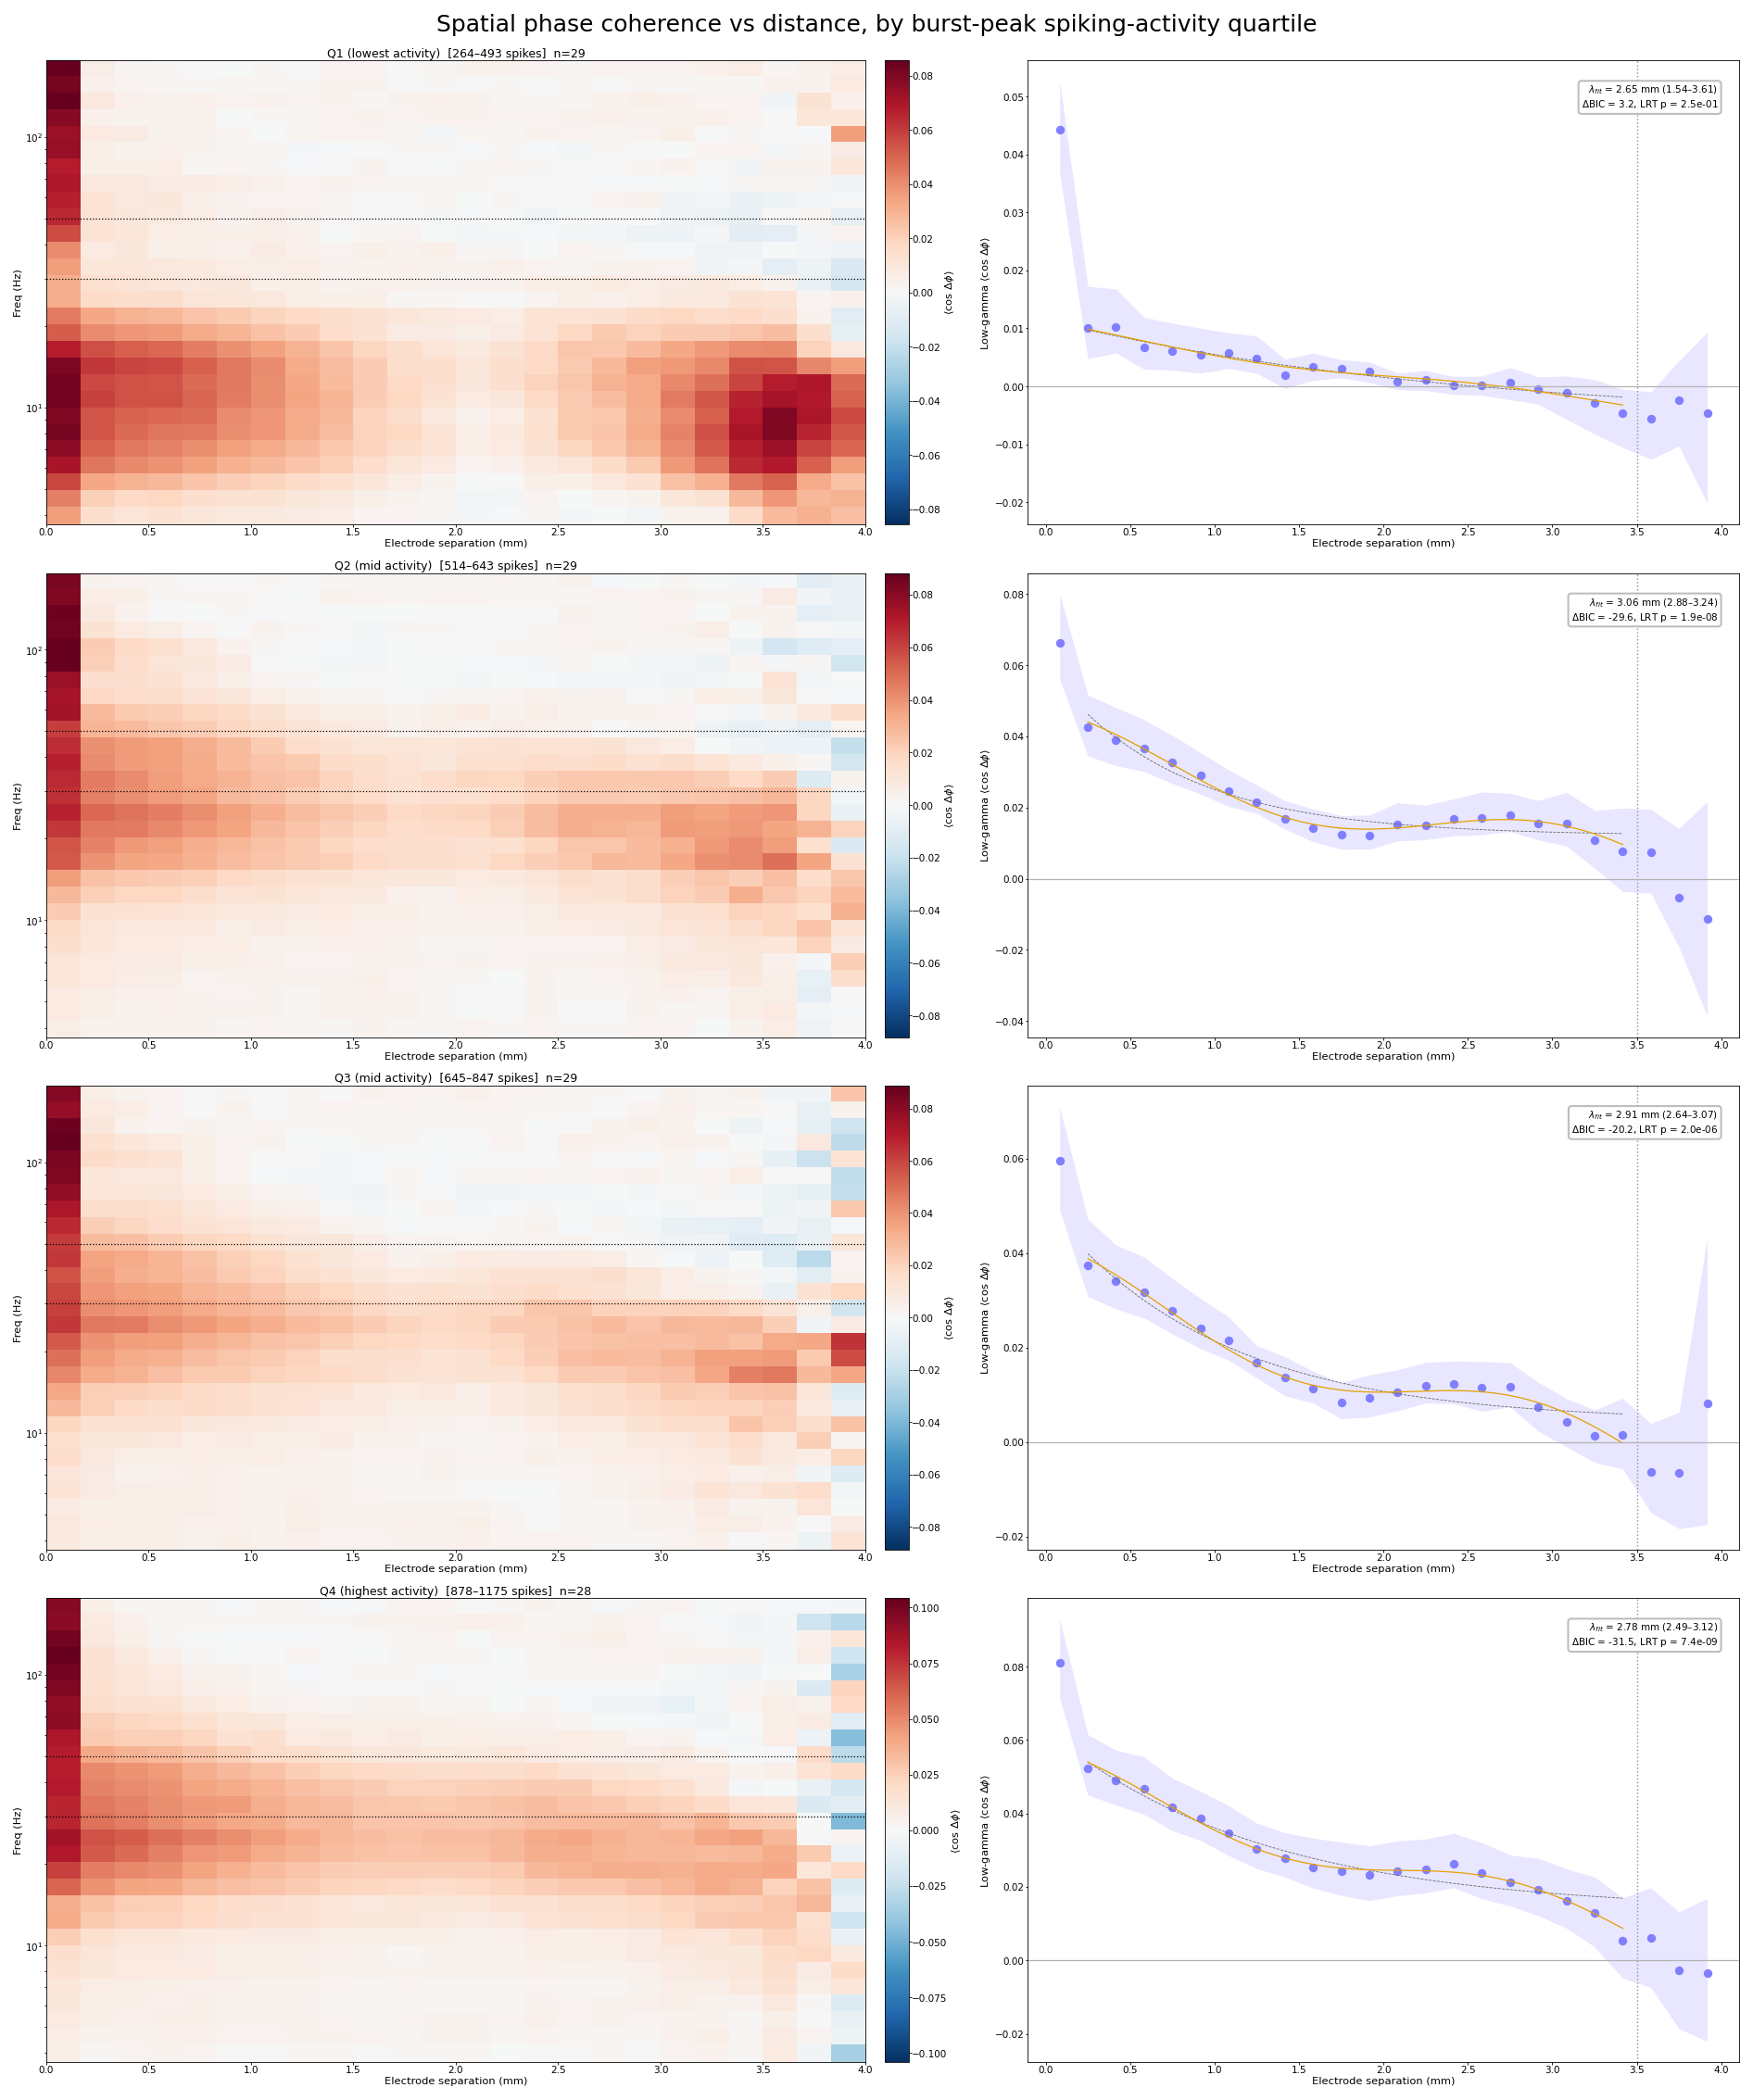

In [21]:
# --- Coherence vs distance split by burst-peak spiking-activity quartile ---
# Rank events by spike count near the anchor (same metric as the GIF selection), split into
# quartiles, and reuse the CACHED per-event maps (cohdist_maps) -- no coherence recomputation.
from ephax.metrics.lfp import load_data_store_spikes, dataset_for_well

QUARTILE_PRE_MS = float(globals().get("LFP_EVENT_GIF_PRE_MS", 25.0))
QUARTILE_POST_MS = float(globals().get("LFP_EVENT_GIF_POST_MS", 40.0))

_anchor_lookup = {
    (int(w), int(e)): float(a)
    for w, e, a in event_df[["well", "event_idx", "anchor_time_s"]].dropna().itertuples(index=False, name=None)
}
_spikes_by_well = {}
for _w in sorted({int(w) for w, _ in cohdist_meta}):
    _sp, _, _ = load_data_store_spikes(STIM_REMOVAL_NULL_LFP_FILE, dataset_for_well(_w), min_amp=MIN_AMP)
    _spikes_by_well[_w] = np.asarray(_sp["time"], dtype=float)

_pre_s, _post_s = QUARTILE_PRE_MS / 1000.0, QUARTILE_POST_MS / 1000.0
event_activity = np.full(len(cohdist_meta), np.nan)
for i, (w, e) in enumerate(cohdist_meta):
    a = _anchor_lookup.get((int(w), int(e)), np.nan)
    if np.isfinite(a):
        st = _spikes_by_well[int(w)]
        event_activity[i] = float(np.count_nonzero((st >= a - _pre_s) & (st <= a + _post_s)))

# equal-count quartiles by rank (robust to ties in spike counts); Q1 lowest -> Q4 highest activity
_order = np.flatnonzero(np.isfinite(event_activity))
_order = _order[np.argsort(event_activity[_order], kind="stable")]
quartile = np.full(len(cohdist_meta), -1, dtype=int)
quartile[_order] = np.floor(np.arange(_order.size) * 4 / max(_order.size, 1)).astype(int)
print("events per quartile:", [int(np.count_nonzero(quartile == q)) for q in range(4)],
      "| activity range:", (float(np.nanmin(event_activity)), float(np.nanmax(event_activity))))


def _fit_lowgamma(maps_sub, rng):
    ev_cr = np.nanmean(maps_sub[:, lowgamma_mask, :], axis=1)          # (n_sub, n_bins)
    pooled = np.nanmean(ev_cr, axis=0)
    fmask = np.isfinite(pooled) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM) & (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM)
    r_fit, w_fit = cohdist_centers[fmask], cohdist_pair_counts[fmask]
    n_ev = ev_cr.shape[0]
    boot = np.full((COHDIST_BOOTSTRAP_REPS, cohdist_centers.size), np.nan)
    boot_wl = np.full(COHDIST_BOOTSTRAP_REPS, np.nan)
    for bi in range(COHDIST_BOOTSTRAP_REPS):
        idx = rng.integers(0, n_ev, n_ev)
        yb = np.nanmean(ev_cr[idx], axis=0)
        boot[bi] = yb
        m = np.isfinite(yb) & (cohdist_centers <= COHDIST_FIT_MAX_DIST_MM) & (cohdist_centers >= COHDIST_FIT_MIN_DIST_MM)
        if m.sum() >= 6:
            try:
                _, pf, _, _ = _fit_coh_models(cohdist_centers[m], yb[m], cohdist_pair_counts[m])
                boot_wl[bi] = pf[4]
            except Exception:
                pass
    ci_lo, ci_hi = np.nanpercentile(boot, [2.5, 97.5], axis=0)
    p_exp, p_full, rss_exp, rss_full = _fit_coh_models(r_fit, pooled[fmask], w_fit)
    n_fit = r_fit.size
    chi2 = n_fit * np.log(rss_exp / rss_full)
    return {
        "pooled": pooled, "ci_lo": ci_lo, "ci_hi": ci_hi, "p_exp": p_exp, "p_full": p_full,
        "r_fit": r_fit, "wavelength": float(p_full[4]),
        "wl_ci": tuple(np.nanpercentile(boot_wl, [2.5, 97.5])),
        "dbic": n_fit * np.log(rss_full / rss_exp) + 2.0 * np.log(n_fit),
        "lrt_p": float(_chi2_dist.sf(chi2, 2)), "rss_red": 100.0 * (1.0 - rss_full / rss_exp),
    }


def _draw_quartile_row(maps_sub, ax_h, ax_l, title, rng):
    agg = np.ma.masked_invalid(np.nanmean(maps_sub, axis=0))
    vmax = max(float(np.abs(agg).max()) if agg.count() else 1.0, np.finfo(float).eps)
    mesh = ax_h.pcolormesh(cohdist_centers, coh_band_centers, agg, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    for edge in (COHDIST_LOWGAMMA_HZ[0], COHDIST_LOWGAMMA_HZ[1]):
        ax_h.axhline(edge, color="k", lw=0.6, ls=":")
    ax_h.set_yscale("log")
    ax_h.set(xlabel="Electrode separation (mm)", ylabel="Freq (Hz)", title=title)
    ax_h.figure.colorbar(mesh, ax=ax_h, pad=0.015).set_label(r"$\langle\cos\,\Delta\phi\rangle$")

    f = _fit_lowgamma(maps_sub, rng)
    ax_l.fill_between(cohdist_centers, f["ci_lo"], f["ci_hi"], color=FIGURE3_PRIMARY_COLOR, alpha=0.18, linewidth=0)
    ax_l.plot(cohdist_centers, f["pooled"], "o", color=FIGURE3_PRIMARY_COLOR, ms=3.5)
    r_dense = np.linspace(f["r_fit"].min(), f["r_fit"].max(), 200)
    ax_l.plot(r_dense, _coh_exp_model(r_dense, *f["p_exp"]), ls="--", color="0.4", lw=LINE_WIDTHS["base"])
    ax_l.plot(r_dense, _coh_expcos_model(r_dense, *f["p_full"]), ls="-", color=FIGURE3_ACCENT_COLOR, lw=LINE_WIDTHS["emphasis"])
    ax_l.axvline(COHDIST_FIT_MAX_DIST_MM, color="0.6", lw=0.7, ls=":")
    ax_l.axhline(0.0, color="0.7", lw=0.6)
    ax_l.text(0.97, 0.95,
              f"$\\lambda_{{fit}}$ = {f['wavelength']:.2f} mm ({f['wl_ci'][0]:.2f}–{f['wl_ci'][1]:.2f})\n"
              f"$\\Delta$BIC = {f['dbic']:.1f}, LRT p = {f['lrt_p']:.1e}",
              transform=ax_l.transAxes, ha="right", va="top", fontsize=FONT_SIZES.get("small", 8),
              bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.85))
    ax_l.set(xlabel="Electrode separation (mm)", ylabel=r"Low-gamma $\langle\cos\,\Delta\phi\rangle$")


_qrng = np.random.default_rng(COHDIST_SEED)
fig, axes = plt.subplots(4, 2, figsize=(12.5, 15.0), constrained_layout=True,
                         gridspec_kw={"width_ratios": [1.15, 1.0]})
for q in range(4):
    sel = np.flatnonzero(quartile == q)
    if sel.size < 3:
        for ax in axes[q]:
            ax.set_title(f"Q{q+1}: too few events (n={sel.size})"); ax.axis("off")
        continue
    amin, amax = event_activity[sel].min(), event_activity[sel].max()
    title = f"Q{q+1} ({'lowest' if q==0 else 'highest' if q==3 else 'mid'} activity)  [{amin:.0f}–{amax:.0f} spikes]  n={sel.size}"
    _draw_quartile_row(cohdist_maps[sel], axes[q, 0], axes[q, 1], title, _qrng)
fig.suptitle("Spatial phase coherence vs distance, by burst-peak spiking-activity quartile", fontsize=FONT_SIZES.get("large", 12))
plt.show()